In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

In [79]:
train_df = pd.read_csv("fraudTrain.csv")
test_df = pd.read_csv("fraudTest.csv")

train_df = train_df.sample(
    n=100000,
    random_state=42
)

print("Training Dataset Shape :", train_df.shape)
print("Testing Dataset Shape  :", test_df.shape)

Training Dataset Shape : (100000, 23)
Testing Dataset Shape  : (555719, 23)


In [80]:
display(train_df.head())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1045211,1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,Spring Church,PA,15686,40.6153,-79.4545,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0
547406,547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,Sixes,OR,97476,42.8250,-124.4409,217,Retail merchandiser,1928-10-01,d0ad335af432f35578eea01d639b3621,1345650541,42.758860,-123.636337,0
110142,110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,Keisterville,PA,15449,39.9636,-79.7853,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0
1285953,1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,Farmington,NY,14425,42.9580,-77.3083,10717,Cytogeneticist,1952-10-13,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.767506,-76.542384,0
271705,271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,Lagrange,WY,82221,41.6423,-104.1974,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0


In [81]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 1045211 to 1049499
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             100000 non-null  int64  
 1   trans_date_trans_time  100000 non-null  object 
 2   cc_num                 100000 non-null  int64  
 3   merchant               100000 non-null  object 
 4   category               100000 non-null  object 
 5   amt                    100000 non-null  float64
 6   first                  100000 non-null  object 
 7   last                   100000 non-null  object 
 8   gender                 100000 non-null  object 
 9   street                 100000 non-null  object 
 10  city                   100000 non-null  object 
 11  state                  100000 non-null  object 
 12  zip                    100000 non-null  int64  
 13  lat                    100000 non-null  float64
 14  long                   100000 non-

In [82]:
display(train_df.describe())

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.000000e+05,1.000000e+05,100000.00000,100000.000000,100000.000000,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000
mean,6.496177e+05,4.144106e+17,70.09797,48877.432690,38.545307,-90.281210,8.926183e+04,1.349288e+09,38.545636,-90.279953,0.005980
std,3.738727e+05,1.304972e+18,141.31813,26889.271339,5.066987,13.772041,3.057107e+05,1.282166e+07,5.101331,13.782535,0.077099
min,1.300000e+01,6.041621e+10,1.00000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.031242,-166.655425,0.000000
25%,3.259925e+05,1.800400e+14,9.63750,26237.000000,34.690200,-96.809400,7.430000e+02,1.338821e+09,34.761914,-96.923129,0.000000
50%,6.494685e+05,3.518759e+15,47.56000,48174.000000,39.354300,-87.591700,2.457000e+03,1.349299e+09,39.357916,-87.476149,0.000000
75%,9.735372e+05,4.642255e+15,82.84000,72042.000000,41.940400,-80.175200,2.032800e+04,1.359462e+09,41.952371,-80.289363,0.000000
max,1.296673e+06,4.992346e+18,9092.75000,99783.000000,66.693300,-67.950300,2.906700e+06,1.371817e+09,67.397018,-66.963918,1.000000


In [83]:
missing = train_df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

display(missing)

,0


In [84]:
duplicates = train_df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [85]:
train_df["is_fraud"].value_counts()

,count
is_fraud,
0,99402
1,598


/tmp/ipykernel_1206/3389141253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


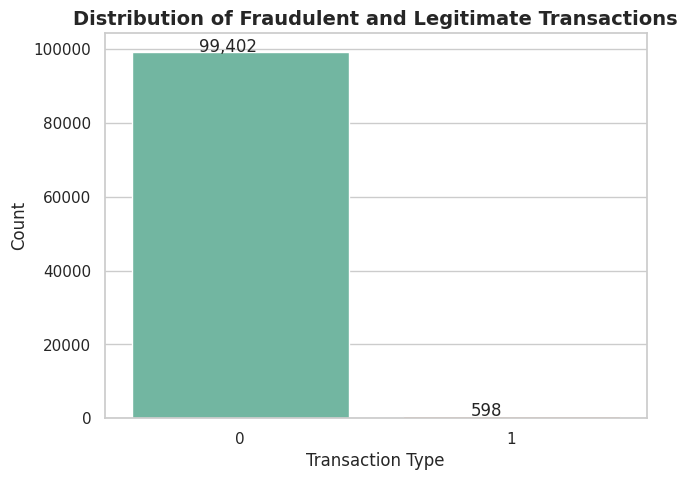

In [86]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x="is_fraud",
    data=train_df,
    palette="Set2"
)

plt.title("Distribution of Fraudulent and Legitimate Transactions",
          fontsize=14,
          weight="bold")

plt.xlabel("Transaction Type")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x()+0.25, p.get_height()))

plt.show()

In [87]:
df = train_df.copy()

In [88]:
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Number of Numerical Features : {len(numerical_cols)}")
print(f"Number of Categorical Features : {len(categorical_cols)}")

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Number of Numerical Features : 11
Number of Categorical Features : 12

Numerical Columns:
['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

Categorical Columns:
['trans_date_trans_time', 'merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num']


In [89]:
display(df["amt"].describe())

,amt
count,100000.00000
mean,70.09797
std,141.31813
min,1.00000
25%,9.63750
50%,47.56000
75%,82.84000
max,9092.75000


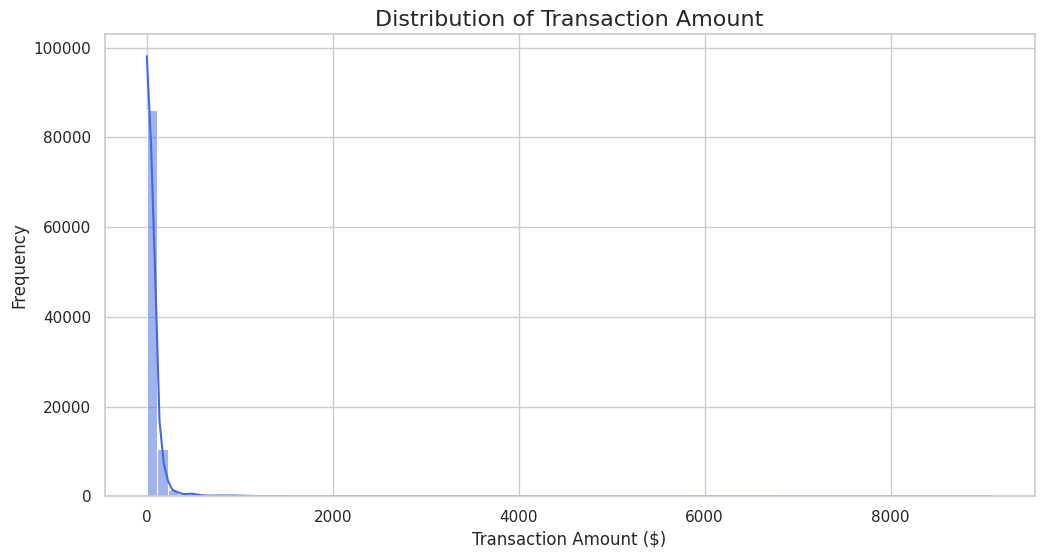

In [90]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["amt"],
    bins=80,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Transaction Amount",fontsize=16)
plt.xlabel("Transaction Amount ($)")
plt.ylabel("Frequency")

plt.show()

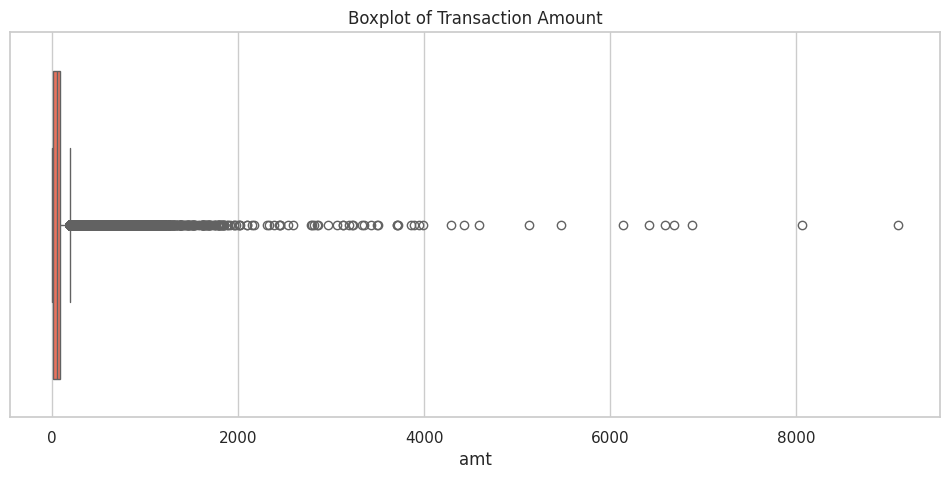

In [91]:
plt.figure(figsize=(12,5))

sns.boxplot(
    x=df["amt"],
    color="tomato"
)

plt.title("Boxplot of Transaction Amount")

plt.show()

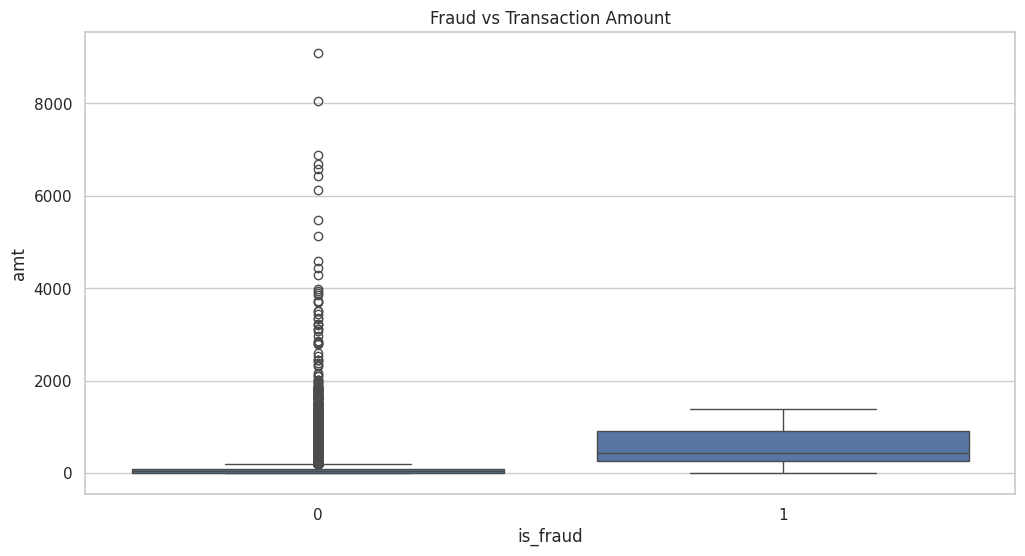

In [92]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="is_fraud",
    y="amt",
    data=df
)

plt.title("Fraud vs Transaction Amount")

plt.show()

In [93]:
fraud_rate = df.groupby("gender")["is_fraud"].mean()*100

fraud_rate.sort_values(ascending=False)

,is_fraud
gender,
M,0.679689
F,0.529906


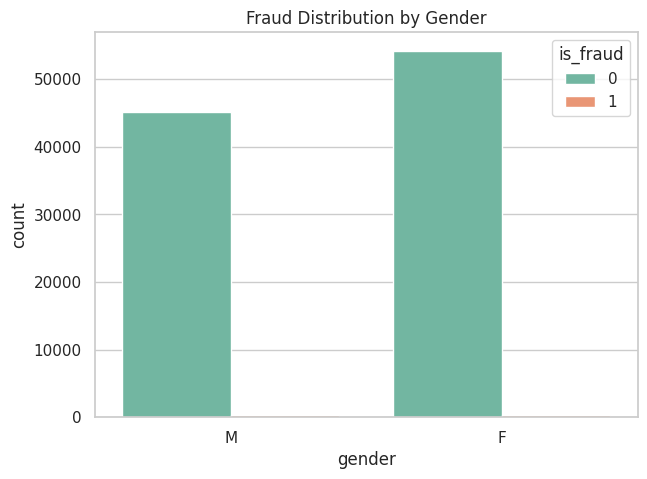

In [94]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="gender",
    hue="is_fraud",
    data=df,
    palette="Set2"
)

plt.title("Fraud Distribution by Gender")

plt.show()

In [95]:
category_counts = (
    df.groupby("category")["is_fraud"]
    .sum()
    .sort_values(ascending=False)
)

display(category_counts.head(15))

,is_fraud
category,
shopping_net,142
grocery_pos,136
shopping_pos,73
misc_net,66
gas_transport,49
misc_pos,24
home,21
entertainment,21
personal_care,18


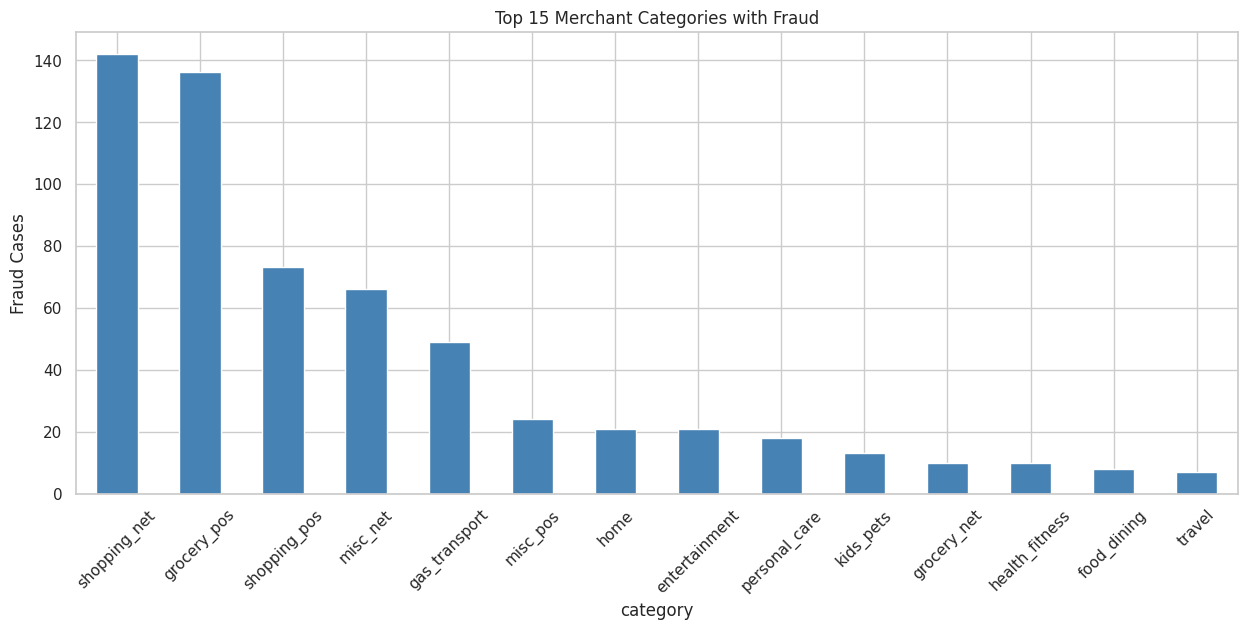

In [96]:
plt.figure(figsize=(15,6))

category_counts.head(15).plot(
    kind="bar",
    color="steelblue"
)

plt.ylabel("Fraud Cases")

plt.title("Top 15 Merchant Categories with Fraud")

plt.xticks(rotation=45)

plt.show()

In [97]:
merchant_counts = (
    df.groupby("merchant")["is_fraud"]
    .sum()
    .sort_values(ascending=False)
)

merchant_counts.head(15)

,is_fraud
merchant,
fraud_Pacocha-O'Reilly,9
"fraud_Osinski, Ledner and Leuschke",7
fraud_Rempel Inc,7
fraud_Jast Ltd,6
fraud_Kozey-Boehm,6
fraud_Kuhic LLC,6
fraud_Strosin-Cruickshank,6
fraud_Stamm-Witting,6
"fraud_Schmeler, Bashirian and Price",6


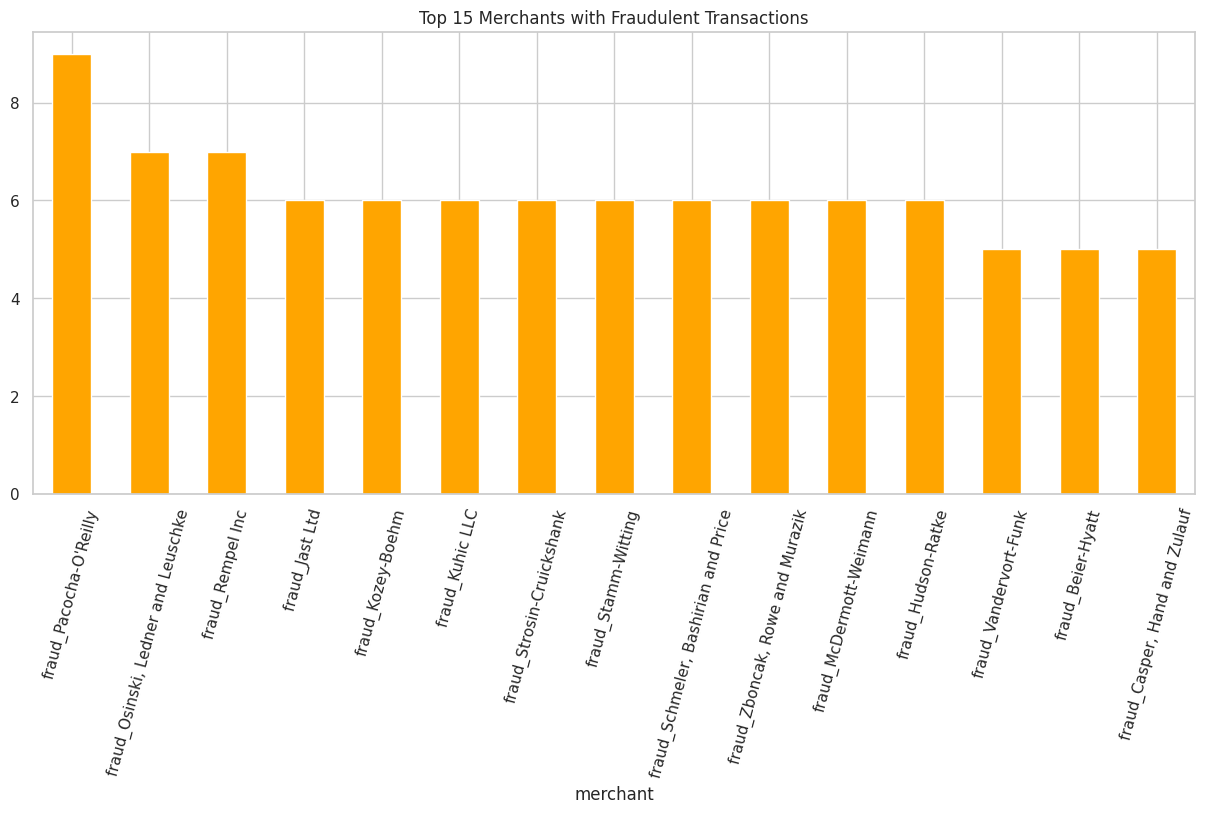

In [98]:
plt.figure(figsize=(15,6))

merchant_counts.head(15).plot(
    kind="bar",
    color="orange"
)

plt.title("Top 15 Merchants with Fraudulent Transactions")

plt.xticks(rotation=75)

plt.show()

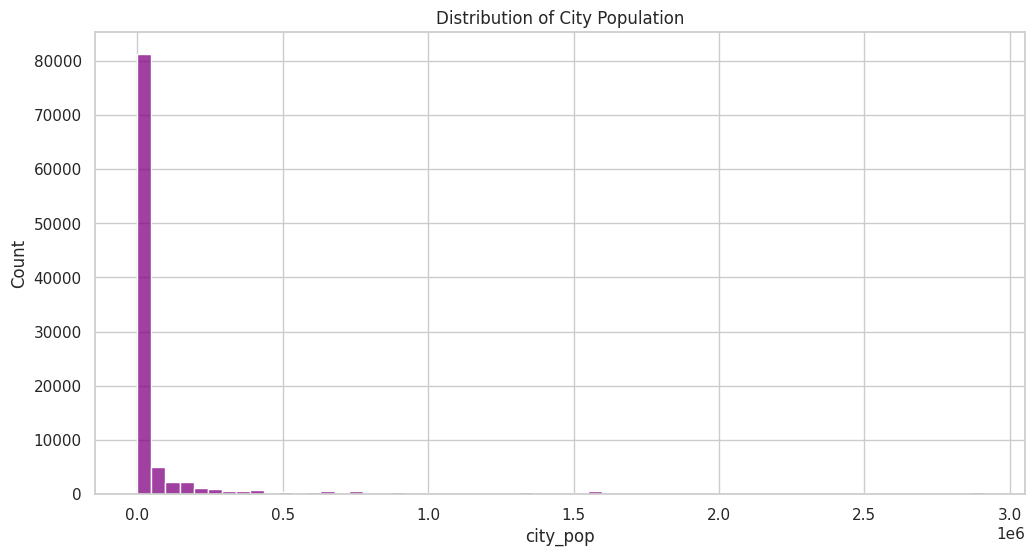

In [99]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["city_pop"],
    bins=60,
    color="purple"
)

plt.title("Distribution of City Population")

plt.show()

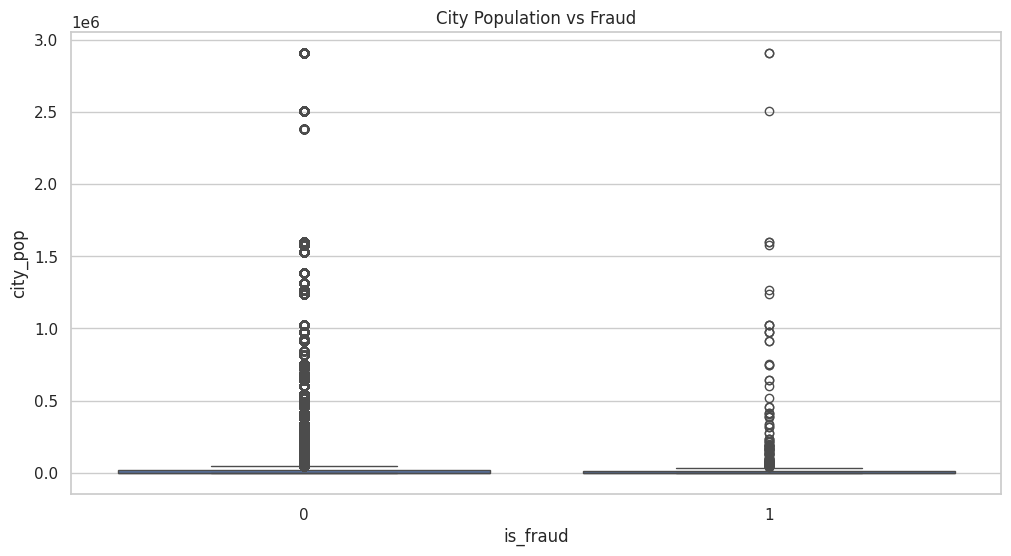

In [100]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="is_fraud",
    y="city_pop",
    data=df
)

plt.title("City Population vs Fraud")

plt.show()

In [101]:
top_jobs = (
    df["job"]
    .value_counts()
    .head(15)
)

top_jobs

,count
job,
Film/video editor,784
Exhibition designer,719
"Surveyor, land/geomatics",675
Naval architect,669
Materials engineer,622
"Designer, ceramics/pottery",608
Systems developer,606
"Copywriter, advertising",601
Financial adviser,586


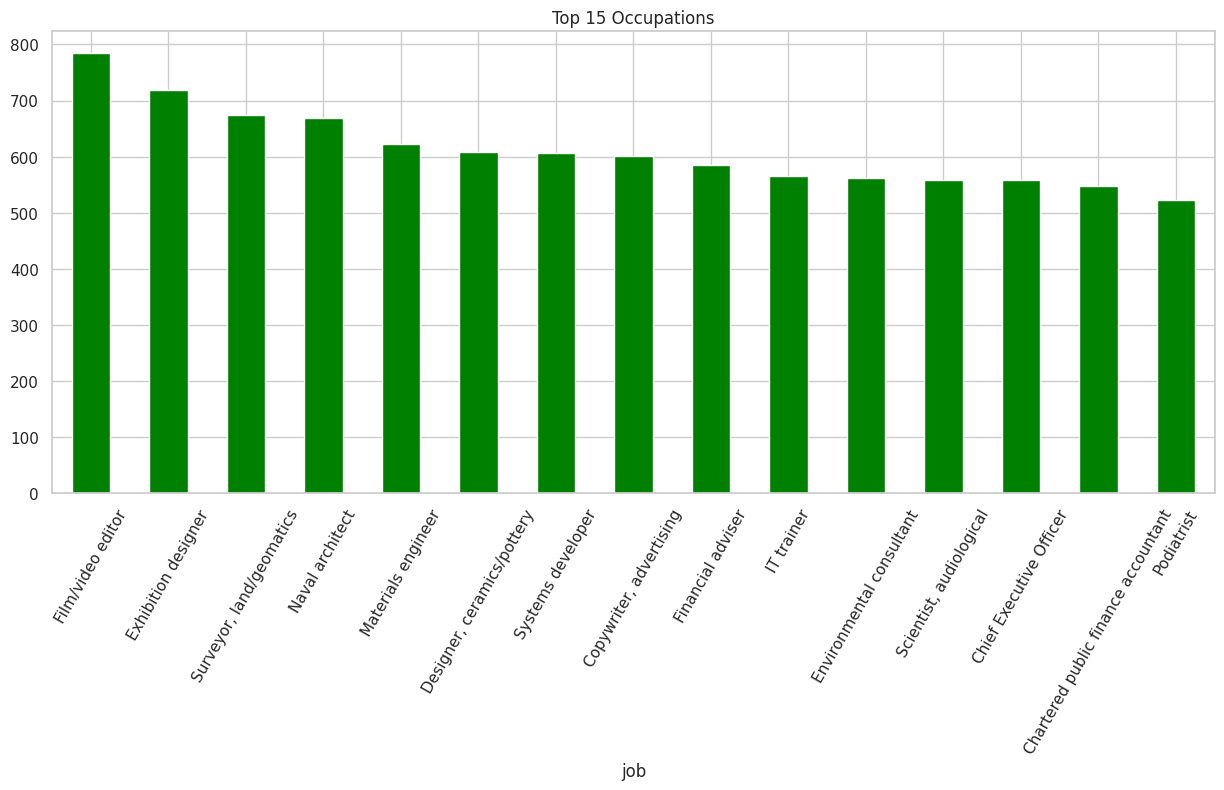

In [102]:
plt.figure(figsize=(15,6))

top_jobs.plot(
    kind="bar",
    color="green"
)

plt.title("Top 15 Occupations")

plt.xticks(rotation=60)

plt.show()

In [103]:
fraud_jobs = (
    df.groupby("job")["is_fraud"]
    .sum()
    .sort_values(ascending=False)
)

fraud_jobs.head(15)

,is_fraud
job,
Television/film/video producer,6
Quantity surveyor,6
Historic buildings inspector/conservation officer,6
Trading standards officer,6
Applications developer,5
Lawyer,5
Naval architect,5
Social researcher,5
Insurance risk surveyor,5


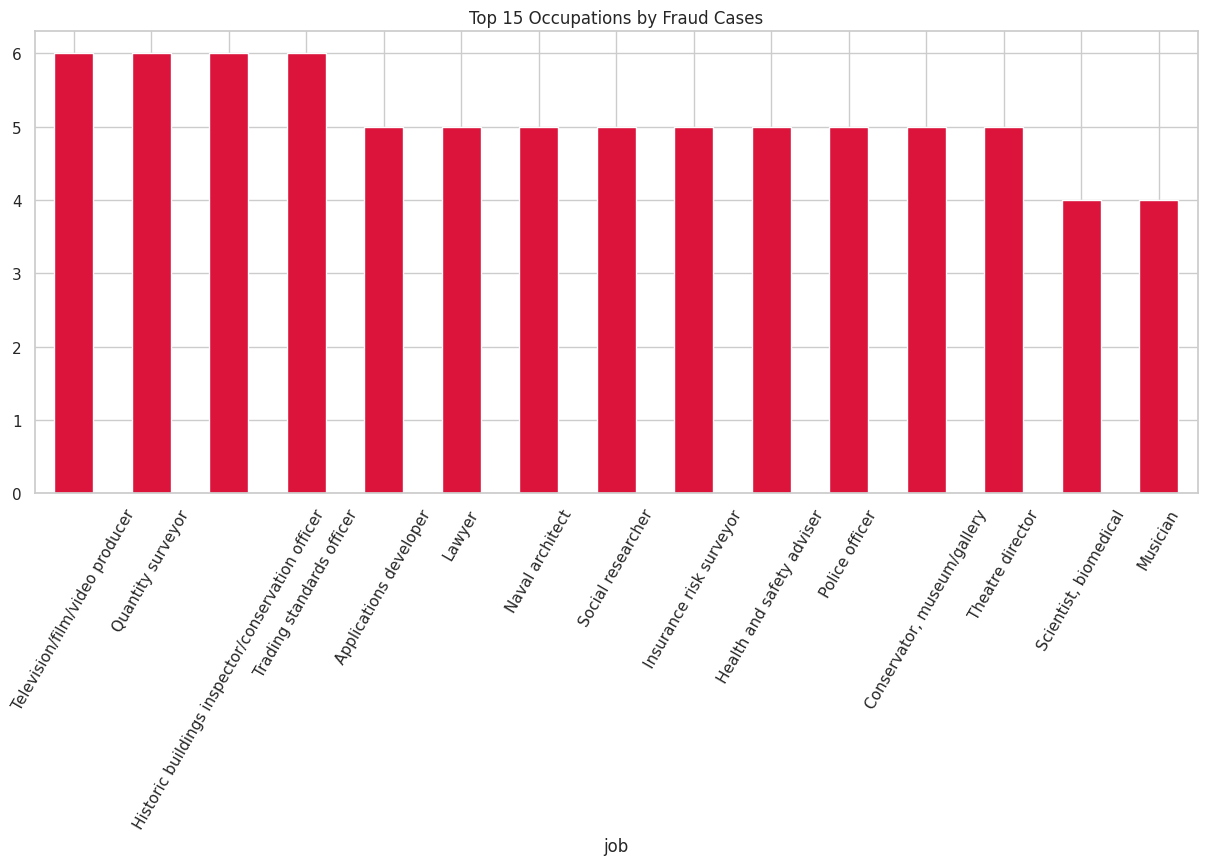

In [104]:
plt.figure(figsize=(15,6))

fraud_jobs.head(15).plot(
    kind="bar",
    color="crimson"
)

plt.title("Top 15 Occupations by Fraud Cases")

plt.xticks(rotation=60)

plt.show()

In [105]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

df["hour"] = df["trans_date_trans_time"].dt.hour

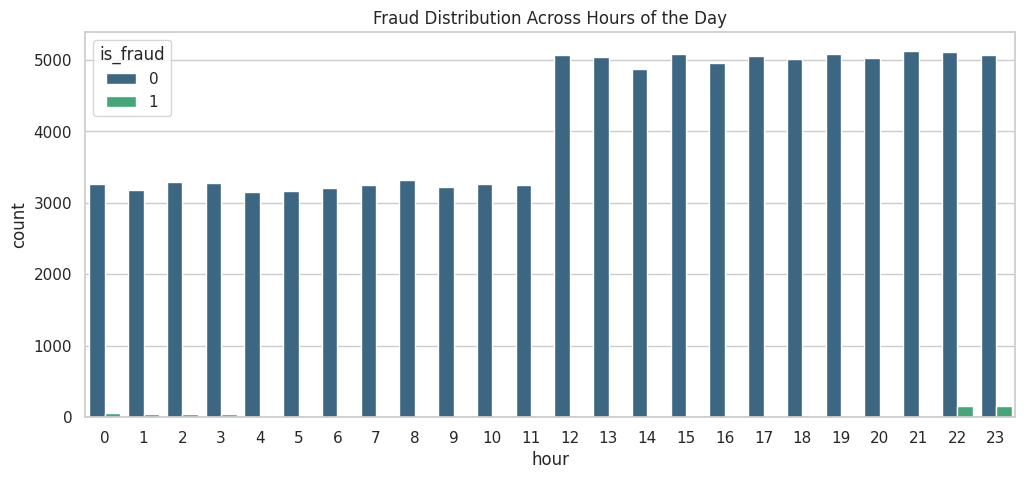

In [106]:
plt.figure(figsize=(12,5))

sns.countplot(
    x="hour",
    hue="is_fraud",
    data=df,
    palette="viridis"
)

plt.title("Fraud Distribution Across Hours of the Day")

plt.show()

In [107]:
train = train_df.copy()
test = test_df.copy()

In [108]:
for df in [train, test]:
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
    df["dob"] = pd.to_datetime(df["dob"])

In [109]:
for df in [train, test]:

    df["transaction_hour"] = df["trans_date_trans_time"].dt.hour
    df["transaction_day"] = df["trans_date_trans_time"].dt.day
    df["transaction_month"] = df["trans_date_trans_time"].dt.month
    df["transaction_year"] = df["trans_date_trans_time"].dt.year
    df["transaction_weekday"] = df["trans_date_trans_time"].dt.day_name()

In [110]:
for df in [train, test]:

    df["is_weekend"] = (
        df["trans_date_trans_time"]
        .dt.weekday
        .isin([5, 6])
        .astype(int)
    )

In [111]:
for df in [train, test]:

    df["is_night_transaction"] = (
        df["transaction_hour"]
        .between(0, 5)
        .astype(int)
    )

In [112]:
for df in [train, test]:

    df["customer_age"] = (
        df["trans_date_trans_time"].dt.year
        - df["dob"].dt.year
    )

In [113]:
bins = [18, 30, 45, 60, 100]

labels = [
    "Young Adult",
    "Adult",
    "Middle Age",
    "Senior"
]

for df in [train, test]:

    df["age_group"] = pd.cut(
        df["customer_age"],
        bins=bins,
        labels=labels
    )

In [114]:
for df in [train, test]:

    df["amt_to_city_pop_ratio"] = (
        df["amt"] /
        (df["city_pop"] + 1)
    )

In [115]:
for df in [train, test]:

    df["log_amt"] = np.log1p(df["amt"])

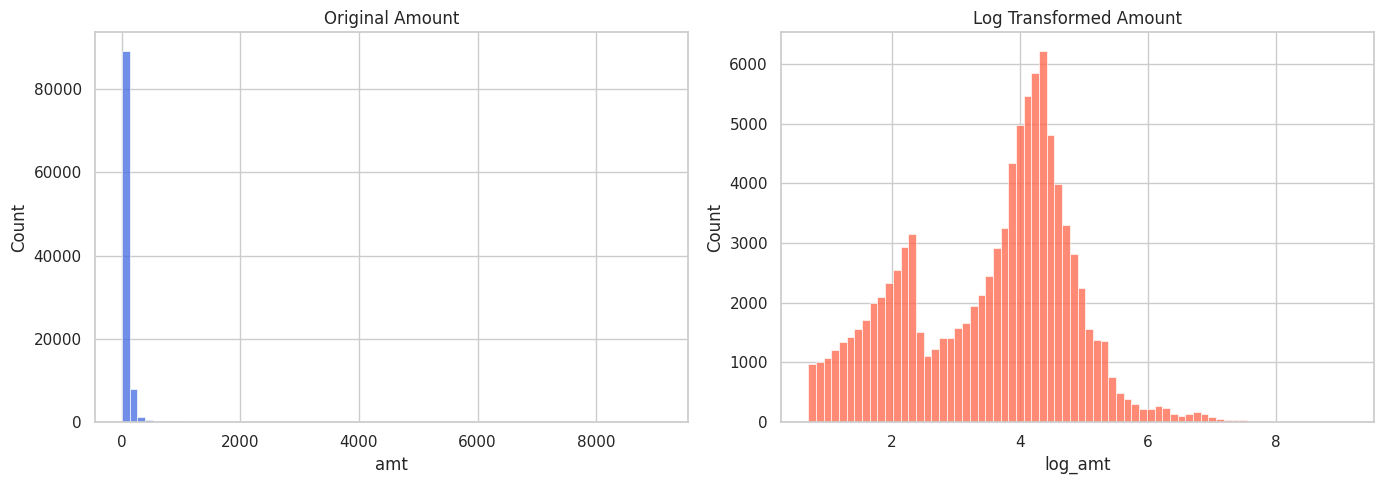

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train["amt"], bins=70, ax=axes[0], color="royalblue")
axes[0].set_title("Original Amount")

sns.histplot(train["log_amt"], bins=70, ax=axes[1], color="tomato")
axes[1].set_title("Log Transformed Amount")

plt.tight_layout()
plt.show()

In [117]:
threshold = train["amt"].quantile(0.90)

for df in [train, test]:

    df["high_amount_transaction"] = (
        df["amt"] >= threshold
    ).astype(int)

In [118]:
new_features = [

    "transaction_hour",
    "transaction_day",
    "transaction_month",
    "transaction_weekday",
    "customer_age",
    "age_group",
    "is_weekend",
    "is_night_transaction",
    "amt_to_city_pop_ratio",
    "log_amt",
    "high_amount_transaction"

]

display(train[new_features].head())

,transaction_hour,transaction_day,transaction_month,transaction_weekday,customer_age,age_group,is_weekend,is_night_transaction,amt_to_city_pop_ratio,log_amt,high_amount_transaction
1045211,15,9,3,Monday,23,Young Adult,0,0,0.199908,5.275612,1
547406,15,22,8,Thursday,91,Senior,0,0,0.240000,3.976311,0
110142,1,4,3,Monday,74,Senior,0,1,0.035297,2.018895,0
1285953,20,16,6,Tuesday,68,Senior,0,0,0.000684,2.119863,0
271705,5,14,5,Tuesday,46,Middle Age,0,1,0.101085,4.178839,0


In [119]:
drop_columns = [

    "Unnamed: 0",
    "trans_date_trans_time",
    "cc_num",
    "first",
    "last",
    "street",
    "trans_num",
    "dob"

]

train.drop(columns=drop_columns, inplace=True)
test.drop(columns=drop_columns, inplace=True)

In [120]:
print(f"Training Shape : {train.shape}")
print(f"Testing Shape  : {test.shape}")

display(train.head())

Training Shape : (100000, 27)
Testing Shape  : (555719, 27)


,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,transaction_hour,transaction_day,transaction_month,transaction_year,transaction_weekday,is_weekend,is_night_transaction,customer_age,age_group,amt_to_city_pop_ratio,log_amt,high_amount_transaction
1045211,fraud_Towne LLC,misc_pos,194.51,M,Spring Church,PA,15686,40.6153,-79.4545,972,Public relations account executive,1362841766,40.420453,-78.865012,0,15,9,3,2020,Monday,0,0,23,Young Adult,0.199908,5.275612,1
547406,fraud_Friesen Ltd,health_fitness,52.32,F,Sixes,OR,97476,42.8250,-124.4409,217,Retail merchandiser,1345650541,42.758860,-123.636337,0,15,22,8,2019,Thursday,0,0,91,Senior,0.240000,3.976311,0
110142,fraud_Mohr Inc,shopping_pos,6.53,F,Keisterville,PA,15449,39.9636,-79.7853,184,Systems developer,1330824856,40.475159,-78.898190,0,1,4,3,2019,Monday,0,1,74,Senior,0.035297,2.018895,0
1285953,fraud_Gaylord-Powlowski,home,7.33,M,Farmington,NY,14425,42.9580,-77.3083,10717,Cytogeneticist,1371413078,43.767506,-76.542384,0,20,16,6,2020,Tuesday,0,0,68,Senior,0.000684,2.119863,0
271705,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,F,Lagrange,WY,82221,41.6423,-104.1974,635,Product/process development scientist,1336974888,41.040392,-104.092324,0,5,14,5,2019,Tuesday,0,1,46,Middle Age,0.101085,4.178839,0


In [121]:
train.isnull().sum().sort_values(ascending=False).head(15)

,0
age_group,1326
category,0
merchant,0
gender,0
city,0
state,0
zip,0
lat,0
long,0
city_pop,0


In [122]:
display(train.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
merchant,100000,693,fraud_Kilback LLC,362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,100000,14,gas_transport,10077,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amt,100000.0,NaN,NaN,NaN,70.09797,141.31813,1.0,9.6375,47.56,82.84,9092.75
gender,100000,2,F,54538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,100000,865,Birmingham,418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,100000,50,TX,7250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip,100000.0,NaN,NaN,NaN,48877.43269,26889.271339,1257.0,26237.0,48174.0,72042.0,99783.0
lat,100000.0,NaN,NaN,NaN,38.545307,5.066987,20.0271,34.6902,39.3543,41.9404,66.6933
long,100000.0,NaN,NaN,NaN,-90.28121,13.772041,-165.6723,-96.8094,-87.5917,-80.1752,-67.9503
city_pop,100000.0,NaN,NaN,NaN,89261.83144,305710.749021,23.0,743.0,2457.0,20328.0,2906700.0


In [123]:
X_train = train.drop("is_fraud", axis=1)
y_train = train["is_fraud"]

X_test = test.drop("is_fraud", axis=1)
y_test = test["is_fraud"]

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

Training Features : (100000, 26)
Testing Features : (555719, 26)


In [124]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Features:")
print(categorical_cols)

print("\nNumerical Features:")
print(numerical_cols)

Categorical Features:
['merchant', 'category', 'gender', 'city', 'state', 'job', 'transaction_weekday', 'age_group']

Numerical Features:
['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_weekend', 'is_night_transaction', 'amt_to_city_pop_ratio', 'log_amt', 'high_amount_transaction']


In [125]:
low_cardinality = [
    "gender",
    "category",
    "age_group",
    "transaction_weekday"
]

high_cardinality = [
    "merchant",
    "city",
    "job",
    "state"
]

In [126]:
for col in low_cardinality + high_cardinality:

    print(f"{col} : {X_train[col].nunique()} unique values")

gender : 2 unique values
category : 14 unique values
age_group : 4 unique values
transaction_weekday : 7 unique values
merchant : 693 unique values
city : 865 unique values
job : 482 unique values
state : 50 unique values


In [127]:
X_train = pd.get_dummies(
    X_train,
    columns=low_cardinality,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=low_cardinality,
    drop_first=True
)

In [128]:
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print(X_train.shape)
print(X_test.shape)

(100000, 45)
(555719, 45)


In [129]:
for col in high_cardinality:

    frequency = X_train[col].value_counts(normalize=True)

    X_train[col] = X_train[col].map(frequency)

    X_test[col] = X_test[col].map(frequency)

    X_test[col] = X_test[col].fillna(0)

In [130]:
print(X_train.select_dtypes(include="object").columns)

Index([], dtype='object')


In [131]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

In [132]:
y_train.value_counts()

,count
is_fraud,
0,99402
1,598


/tmp/ipykernel_1206/3187745373.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


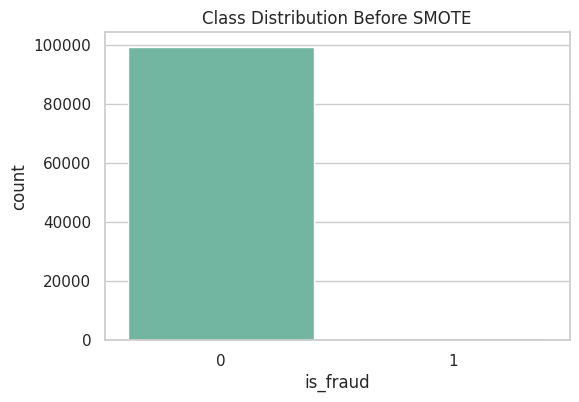

In [133]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=y_train,
    palette="Set2"
)

plt.title("Class Distribution Before SMOTE")

plt.show()

In [134]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42,
    sampling_strategy="auto"
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.shape)

(198804, 45)
(198804,)


In [135]:
pd.Series(y_train_smote).value_counts()

,count
is_fraud,
0,99402
1,99402


/tmp/ipykernel_1206/2907074360.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


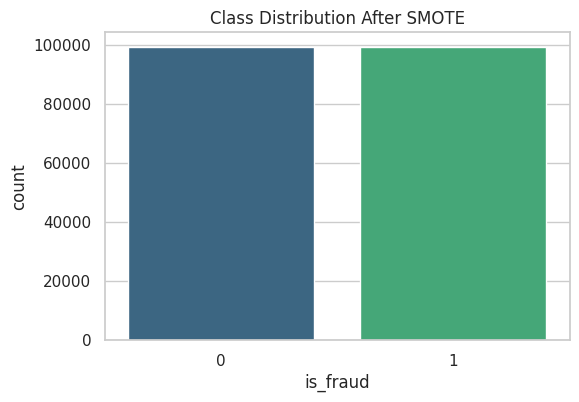

In [136]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=y_train_smote,
    palette="viridis"
)

plt.title("Class Distribution After SMOTE")

plt.show()

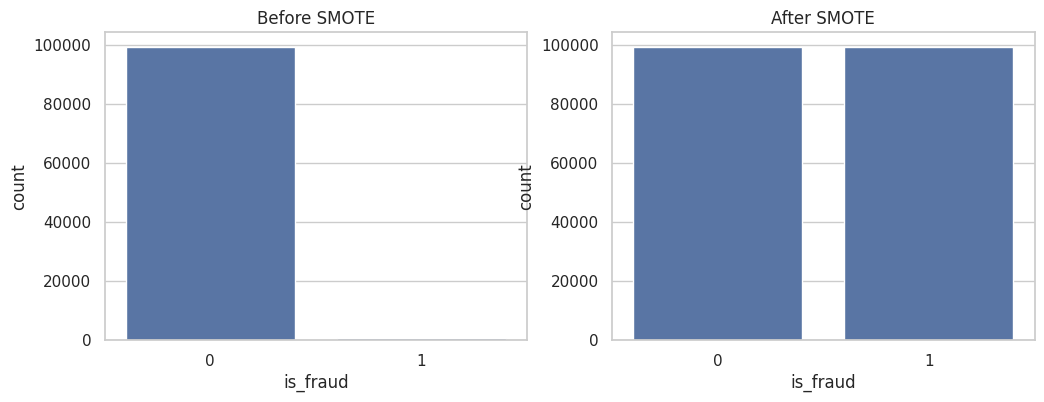

In [137]:
fig, ax = plt.subplots(1,2,figsize=(12,4))

sns.countplot(
    x=y_train,
    ax=ax[0]
)

ax[0].set_title("Before SMOTE")

sns.countplot(
    x=y_train_smote,
    ax=ax[1]
)

ax[1].set_title("After SMOTE")

plt.show()

In [138]:
print("Training Data Shape :", X_train_smote.shape)
print("Testing Data Shape :", X_test.shape)

print("\nTarget Distribution")

print(pd.Series(y_train_smote).value_counts())

Training Data Shape : (198804, 45)
Testing Data Shape : (555719, 45)

Target Distribution
is_fraud
0    99402
1    99402
Name: count, dtype: int64


In [139]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.model_selection import GridSearchCV

In [145]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=50,
            random_state=42,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=50,
            random_state=42,
            n_jobs=-1
        )

}

In [141]:
from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score

)

In [142]:
import time

In [143]:
print(train.shape)
print(X_train.shape)
print(X_train_smote.shape)

(100000, 27)
(100000, 45)
(198804, 45)


In [148]:
results = []

trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    start = time.time()

    model.fit(
        X_train_smote,
        y_train_smote
    )

    train_time = time.time() - start

    trained_models[name] = model

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:, 1]

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, pred),

        "Precision": precision_score(y_test, pred),

        "Recall": recall_score(y_test, pred),

        "F1 Score": f1_score(y_test, pred),

        "ROC AUC": roc_auc_score(y_test, prob),

        "Training Time (s)": round(train_time, 2)

    })

    print(f"✅ {name} completed in {train_time:.2f} seconds.")

print("\n🎉 All models trained successfully!")


Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ Logistic Regression completed in 94.25 seconds.

Training Decision Tree...
✅ Decision Tree completed in 8.83 seconds.

Training Random Forest...
✅ Random Forest completed in 36.67 seconds.

Training Extra Trees...
✅ Extra Trees completed in 12.04 seconds.

🎉 All models trained successfully!


In [151]:
# Model Performace Summary
results_df = results_df.round({
    "Accuracy": 3,
    "Precision": 3,
    "Recall": 3,
    "F1 Score": 3,
    "ROC AUC": 3,
    "Training Time (s)": 2
})

results_df = results_df.sort_values("F1 Score", ascending=False)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
2,Random Forest,0.998,0.872,0.600,0.711,0.977,36.67
3,Extra Trees,0.998,0.952,0.463,0.623,0.947,12.04
1,Decision Tree,0.995,0.387,0.675,0.492,0.835,8.83
0,Logistic Regression,0.956,0.060,0.716,0.111,0.923,94.25


Random Forest achieved the highest F1-score (0.711) and ROC-AUC (0.977), making it the most suitable model for this fraud detection task. Although Logistic Regression achieved a high recall, its very low precision resulted in many false positives. Therefore, Random Forest was selected as the final model due to its balanced performance across all evaluation metrics.

/tmp/ipykernel_1206/515021202.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


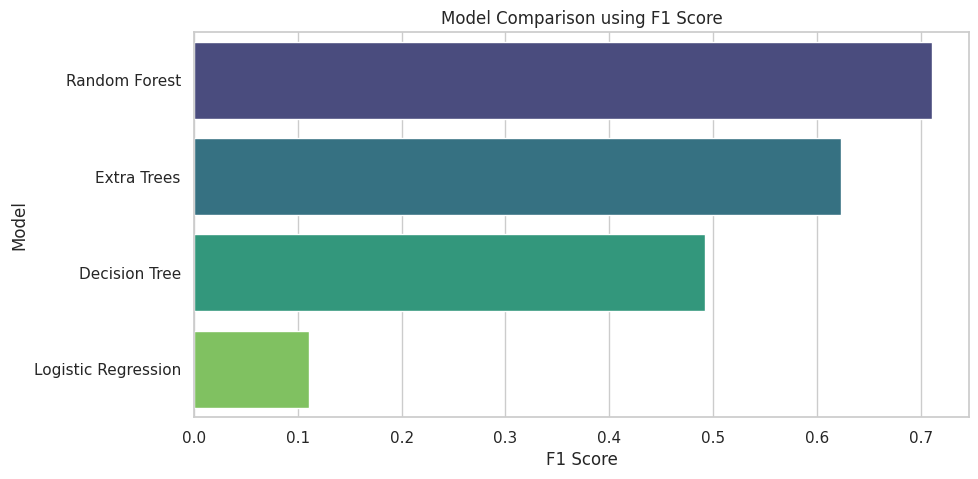

In [152]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results_df.sort_values(
        "F1 Score",
        ascending=False
    ),

    x="F1 Score",
    y="Model",

    palette="viridis"

)

plt.title("Model Comparison using F1 Score")

plt.show()

/tmp/ipykernel_1206/318355747.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


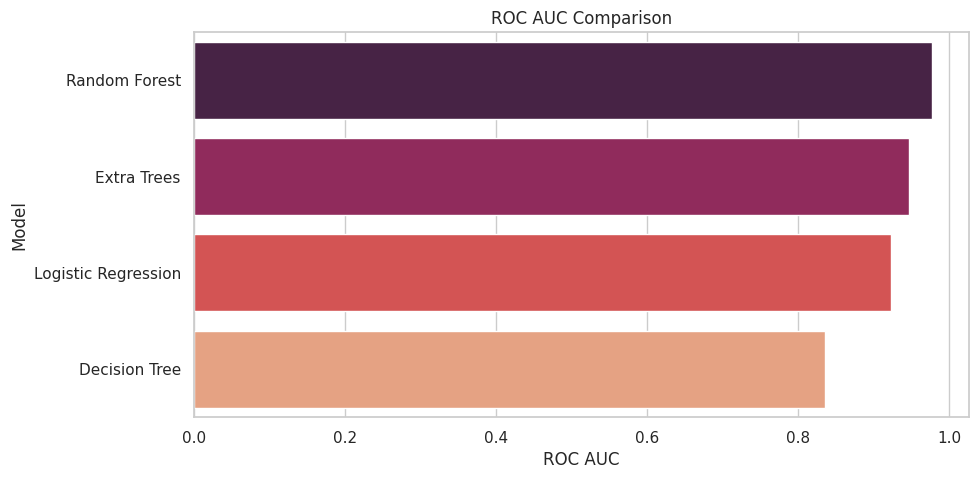

In [153]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results_df.sort_values(
        "ROC AUC",
        ascending=False
    ),

    x="ROC AUC",

    y="Model",

    palette="rocket"

)

plt.title("ROC AUC Comparison")

plt.show()

In [154]:
best_model_name = results_df.sort_values(
    "F1 Score",
    ascending=False
).iloc[0]["Model"]

print(best_model_name)

Random Forest


In [155]:
best_model = trained_models[
    best_model_name
]

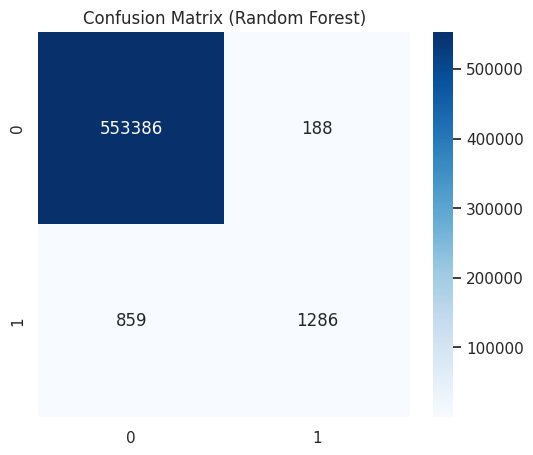

In [156]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    best_model.predict(X_test)
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title(
    f"Confusion Matrix ({best_model_name})"
)

plt.show()

In [157]:
from sklearn.metrics import classification_report

print(

    classification_report(

        y_test,

        best_model.predict(X_test)

    )

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.87      0.60      0.71      2145

    accuracy                           1.00    555719
   macro avg       0.94      0.80      0.85    555719
weighted avg       1.00      1.00      1.00    555719



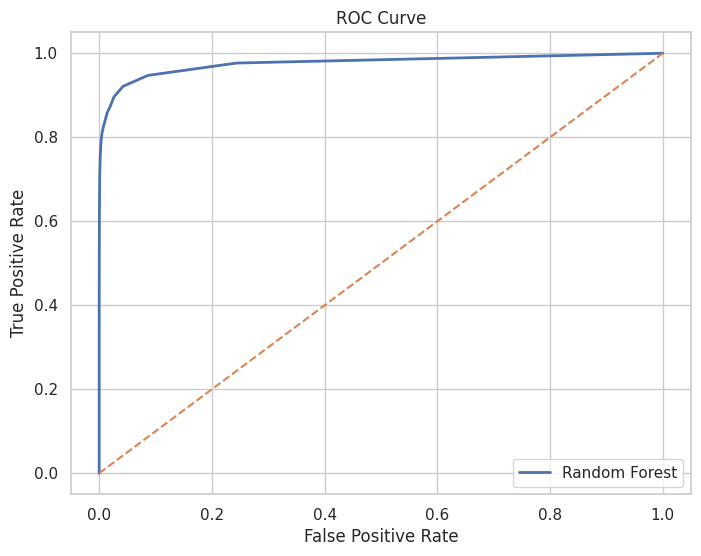

In [158]:
from sklearn.metrics import roc_curve

prob = best_model.predict_proba(
    X_test
)[:,1]

fpr,tpr,_ = roc_curve(
    y_test,
    prob
)

plt.figure(figsize=(8,6))

plt.plot(

    fpr,

    tpr,

    label=best_model_name,

    linewidth=2

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.legend()

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

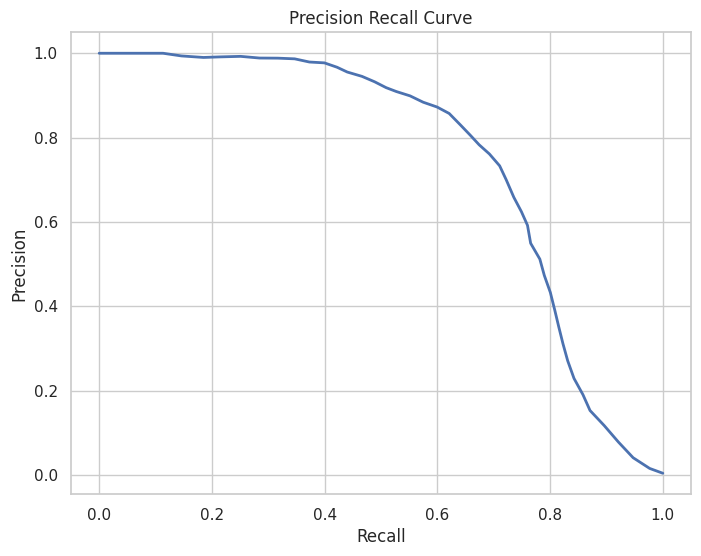

In [161]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, prob)

plt.figure(figsize=(8,6))

plt.plot(

    recall,

    precision,

    linewidth=2

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [178]:
from sklearn.model_selection import train_test_split

X_tune, _, y_tune, _ = train_test_split(
    X_train_smote,
    y_train_smote,
    train_size=50000,
    stratify=y_train_smote,
    random_state=42
)

In [179]:
print(X_tune.shape)

(50000, 45)


In [180]:
grid.fit(X_tune, y_tune)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, None], 'min_samples_split': [2, 5],
                         'n_estimators': [50]},
             scoring='f1')

In [182]:
X_tune, _, y_tune, _ = train_test_split(
    X_train_smote,
    y_train_smote,
    train_size=50000,
    stratify=y_train_smote,
    random_state=42
)

params = {
    "n_estimators": [50],
    "max_depth": [10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_tune, y_tune)

print(grid.best_params_)

best_rf = grid.best_estimator_

{'max_depth': None, 'n_estimators': 50}


In [183]:
best_rf = grid.best_estimator_

In [184]:
rf_pred = best_rf.predict(X_test)

rf_prob = best_rf.predict_proba(X_test)[:,1]

print(

    classification_report(

        y_test,

        rf_pred

    )

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.63      0.71      0.67      2145

    accuracy                           1.00    555719
   macro avg       0.81      0.85      0.83    555719
weighted avg       1.00      1.00      1.00    555719



In [185]:
importance = pd.Series(

    best_rf.feature_importances_,

    index=X_train.columns

).sort_values(
    ascending=False
)

importance.head(20)

,0
amt,0.223735
high_amount_transaction,0.175005
log_amt,0.131209
transaction_hour,0.095702
amt_to_city_pop_ratio,0.045739
is_weekend,0.036857
category_grocery_pos,0.023380
category_shopping_net,0.021524
category_gas_transport,0.021349
is_night_transaction,0.018414


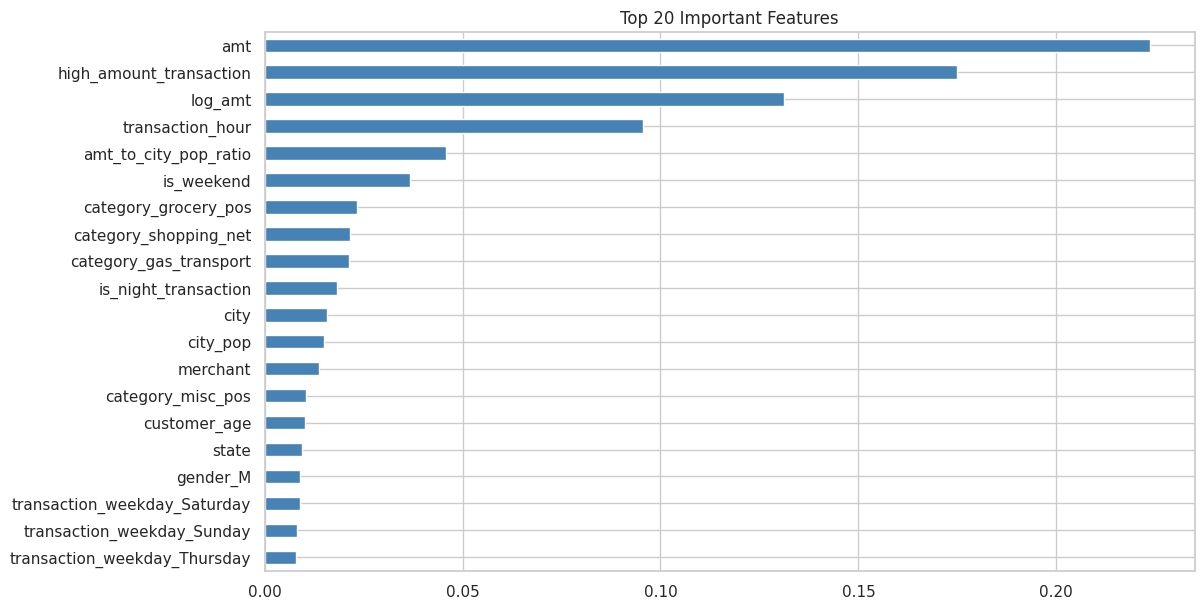

In [186]:
plt.figure(figsize=(12,7))

importance.head(20).plot(

    kind="barh",

    color="steelblue"

)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

In [168]:
results_df.sort_values(

    "F1 Score",

    ascending=False

).style.background_gradient(
    cmap="Greens"
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
2,Random Forest,0.998000,0.872000,0.600000,0.711000,0.977000,36.670000
3,Extra Trees,0.998000,0.952000,0.463000,0.623000,0.947000,12.040000
1,Decision Tree,0.995000,0.387000,0.675000,0.492000,0.835000,8.830000
0,Logistic Regression,0.956000,0.060000,0.716000,0.111000,0.923000,94.250000


In [170]:
print("="*60)
print("PROJECT COMPLETED")
print("="*60)

print(f"Best Model : {best_model_name}")

print("\nThis notebook contains all these task that were listed for the project:")

print("- Exploratory Data Analysis")
print("- Feature Engineering")
print("- Data Preprocessing")
print("- SMOTE")
print("- Model Training")
print("- Hyperparameter Tuning")
print("- Model Evaluation")
print("- Feature Importance")
print("- Model Comparison")

PROJECT COMPLETED
Best Model : Random Forest

This notebook contains all these task that were listed for the project:
- Exploratory Data Analysis
- Feature Engineering
- Data Preprocessing
- SMOTE
- Model Training
- Hyperparameter Tuning
- Model Evaluation
- Feature Importance
- Model Comparison
